In [1]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from qil_helpers.Ben import General as Ben

In [2]:
ground=spin.hamilFromYAML("./ion_params/Er_YSO_site1_ground.yml",IOveride=0)
excited=spin.hamilFromYAML("./ion_params/Er_YSO_site1_excited.yml",IOveride=7/2)
ground=excited
Hcalc=lambda B,self: self.electronicZeeman(B)+self.nuclearZeeman(B)+self.HHF+self.HQP
ground.Hfunc=Hcalc
excited.Hfunc=Hcalc

target=np.array([17.1,9.7,-9.9,-17.6])*1E-3
t1=np.array([9.7,9.9])
t2=np.array([17.1,17.6])

Bfound=np.matrix([ 0.47830596,  0.28797331, -0.15047415]).T*1E-3


print()

{'Spin': {'Espin': '1/2', 'Ispin': '7/2'}, 'Hyperfine': {'A': 'np.matrix([[304.8,-252.8,-307.6],[-252.8,778.0,710.2],[-307.6,710.2,616.2]])*1e6*h', 'A_rot': 'np.array([0,0,0])'}, 'Quadrupole': {'Q': 'np.matrix([[10.1,-10.1,-14.0],[-10.1,-6.3,-15.2],[-14.0,-15.6,-3.8]])*1e6*h', 'Q_rot': 'np.array([0,0,0])'}, 'E_Zeeman': {'g': 'np.matrix([[2.85,-2.98,-3.63],[-2.98,9.00,5.51],[3.63,5.51,5.19]])', 'g_rot': 'np.array([0,0,0])'}, 'N_Zeeman': {'mu': '-0.56'}, 'Oscillator': {'par': 'np.block([[np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])', 'perp': 'np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])', 'perp_T': 'np.block([[np.zeros([odim,odim]),1j*np.eye(odim)],[-1j*np.eye(odim),np.zeros([odim,odim])]])'}}
{'Spin': {'Espin': '1/2', 'Ispin': '7/2'}, 'Hyperfine': {'A': 'np.matrix([[307.9,-327.5,-464.8],[-327.5,607.8,676.7],[-464.8,676.7,980.5]])*1e6*h', 'A_rot': 'np.array([0,0,0])'}, 'Quadrupole': {'Q': 'np.matrix([[56.0,1.66,5.80

In [3]:
foundNorm=np.linalg.norm(Bfound)
Bu=Bfound/foundNorm
Bu=np.matrix([0,0,1]).T

Bs=np.linspace(0,1E-3,500)
#Bu=np.matrix([0,1,1]).T
FSG=np.zeros((len(Bs),ground.dim))
FSE=np.zeros((len(Bs),excited.dim))
Ts=np.zeros((len(Bs),excited.dim*ground.dim))
#Ts=np.zeros((len(Bs),excited.dim**2))


FpG=np.zeros((len(Bs),ground.dim,3))
FpE=np.zeros((len(Bs),excited.dim,3))
Tps=np.zeros((len(Bs),excited.dim*ground.dim,3))
#Tps=np.zeros((len(Bs),excited.dim,3))

Ag=ground.genAMatrix(spin.muB*ground.gE,ground.S,electronic=True)
Ae=excited.genAMatrix(spin.muB*excited.gE,excited.S,electronic=True)

for i,x in enumerate(Bs):
    B = Bu*x            
    HG = ground.calcH(B)
    HE = excited.calcH(B)
 
    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    FSG[i,:]=FG#*1E3

    FE,VE = excited.getEigFreq(HE)
    FSE[i,:]=FE#*1E3
    
    Ts[i,:]=spin.eachElemFunc(FG,FE)
    #Ts[i,:]=spin.eachElemFunc(FE,FE)

    for j in range(3):
        FpG[i,:,j]= ground.firstOrderEnergySensitivity(VG,Ag[j])
        FpE[i,:,j]= excited.firstOrderEnergySensitivity(VE,Ae[j])
    Tps[i,:,:]=spin.eachElemFunc(FpG[i,:,:],FpE[i,:,:],ax=0)
    #Tps[i,:,:]=spin.eachElemFunc(FpE[i,:,:],FpE[i,:,:],ax=0)
    
    #Tps[i,:,:]=FpE[i,:,:]-FpG[i,0,:]

plt.plot(Bs,FSG)
plt.plot(Bs,FSE)
plt.show()
plt.close()

# print(VG)
# print(np.linalg.eigh(HG))

AttributeError: 'cSpinHamiltonian' object has no attribute 'HQP'

Goal is to do gradient descent towards a target to find what magnetic field vector this corresponds to, we seek to minimise the square of the euclidian distance:
$$y=||f(x)-d||^2=(f(x)-d)^{\dagger}(f(x)-d)$$
$$\frac{dy}{dx}=2(f(x)-d)\frac{df(x)}{dx}$$

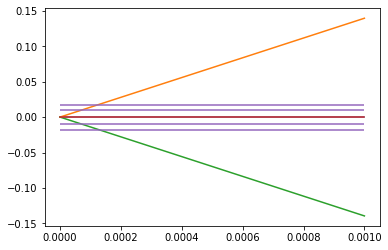

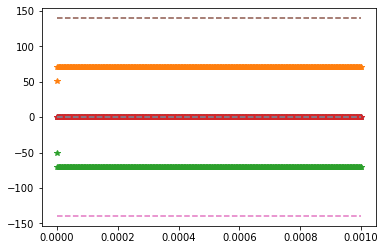

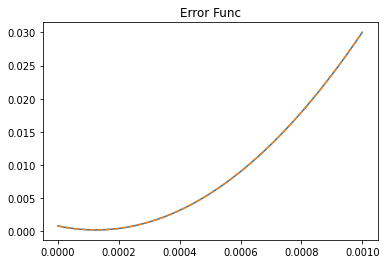

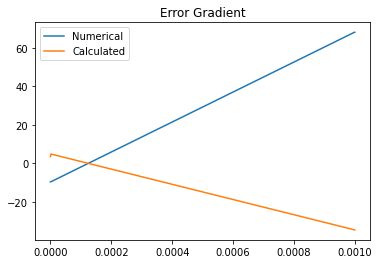

In [4]:
Topt=195.1168E6
#Ts=spin.eachElemFunc(FSG,FSE,ax=1)
idx=np.argsort(Ts)[-1,:]
# print(idx,Ts[-1,idx],Ts[-1,:])
targets=np.array(target)[np.array([1,0,3,2])]
dim=(ground.dim**2)/len(targets)
targets=np.repeat(targets,dim)
#print((dim**2)/len(targets))
# print(Ts.shape,idx.shape)
# #Ts=Ts
# print(Ts.shape)
vecTimes=lambda U,V: np.squeeze(np.einsum('mr,mrd->m',U,V))

#Tps=spin.eachElemFunc(FpG,FpE,ax=1)#[:,idx,:]
plt.plot(Bs,Ts)
plt.hlines(target,Bs[0],Bs[-1],color='C4')
plt.show()
# Tps=spin.eachElemFunc(FpG,FpE,ax=1)#[:,idx,:]
plt.plot(Bs,Tps[:,:,0],'*')
calcgrad=np.gradient(Ts,np.mean(np.diff(Bs)),axis=0)
plt.plot(Bs,calcgrad,linestyle='dashed')
# print(np.mean(Tps[:,:,0]/calcgrad,axis=0))
plt.show()

#Tps[:,:,0]=Tps[:,:,0]/np.matrix([2,1.5,1.5,2])
norm=lambda U: np.squeeze(np.einsum('mr,mr->m',U.conj(),U))

meas=norm(np.matrix(Ts-targets))
bf=np.sum(np.square(Ts-targets),axis=1)
plt.plot(Bs,meas)
plt.plot(Bs,bf,'--')
plt.title("Error Func")
#plt.hlines(target,Bs[0]*1E3,Bs[-1]*1E3,color='C4')
plt.show()

plt.plot(Bs,np.gradient(meas,np.mean(np.diff(Bs)),axis=0),label="Numerical")
#plt.show()
plt.plot(Bs,np.squeeze(np.einsum('mr,mr->m',2*(targets-Ts),Tps[:,:,0])),label="Calculated")
plt.title("Error Gradient")
plt.legend()
#plt.hlines(target,Bs[0]*1E3,Bs[-1]*1E3,color='C4')
plt.show()

In [5]:
norm=lambda U: np.squeeze(U.H@U).item()

def doGradientDescent(B,target,gamma=1):
    HG = ground.calcH(B)
    HE = excited.calcH(B)
 
    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    
    FE,VE = excited.getEigFreq(HE)
    
    FpG=np.zeros((ground.dim,3))
    FpE=np.zeros((ground.dim,3))


    for j in range(3):
        FpG[:,j]= ground.firstOrderEnergySensitivity(VG,Ag[j])
        FpE[:,j]= excited.firstOrderEnergySensitivity(VE,Ae[j])
    T=spin.eachElemFunc(FG,FE)
#    print(T)
    Tp=spin.eachElemFunc(FpG,FpE,ax=0)
#    print(FpG)
#    print(Tp)
    S=-2*(T-target)@Tp
#    print(T.shape,Tp.shape,S.shape)

#    print(S)
    return B-gamma*S,norm(np.matrix(T-target).T),S

def allTargets(targets):
    dim=(ground.dim**2)/len(targets)
    return np.repeat(targets,dim)


def zSplitting(targets,range=[-30E-3,30E-3]):
    zer=np.matrix([0,0,0]).T
    HG=ground.calcH(zer)
    HE=ground.calcH(zer)
    FG,_ = ground.getEigFreq(HG)
    FE,_ = excited.getEigFreq(HE)
    Ts=spin.eachElemFunc(FG,FE)
    idx=np.logical_and(np.where(Ts>=range[0]),np.where(Ts<=range[1]))

    return idx


In [6]:
%%script False
target=np.array([17.1,9.7,-9.9,-17.6])*1E-3
targets=np.array(target)[np.array([1,0,3,2])]
targets=allTargets(targets)

idx=zSplitting(targets)

B=np.random.random(3)*20-10
#B=np.array([-5,-1,0]).T
Bs=[]
Es=[]
for i in range(1000):
    B,E,S=doGradientDescent(B,targets,1E-5)
    Bs.append(B)
    Es.append(E)

plt.plot(Bs)
plt.xscale('log')

plt.show()
plt.plot(np.sqrt(Es))
plt.yscale('log')
plt.xscale('log')

plt.show()
#plt.yscale('log')

print("Final Value %s mT"%(Bs[-1]*1E3))
print("Final Error %s MHz"%np.sqrt(Es[-1]))

def asSpherical(xyz):
    #takes list xyz (single coord)
    x       = xyz[0]
    y       = xyz[1]
    z       = xyz[2]
    r       =  np.sqrt(x*x + y*y + z*z)
    theta   =  np.acos(z/r)*180/ np.pi #to degrees
    phi     =  np.atan2(y,x)*180/ np.pi
    return r,theta,phi


Couldn't find program: 'False'


In [7]:
%%script False
xs=np.linspace(-30,30,500)
# spin.quickAbsorbtion(ground,excited,Bs[-1],0,0,np.eye(3),xs,1e-3)
HG = ground.calcH(B)
HE = excited.calcH(B)

#get the eigen frequencies and vectors at this B field
fg,vg = ground.getEigFreq(HG)
fe,ve = excited.getEigFreq(HE)
fg=fg*1e3
fe=fe*1e3

f = np.real(spin.eachElemFunc(fg,fe))
OS = np.real(spin.TransitionStrength(vg,ve,np.eye(ground.dim),ground.dim))
            
A = spin.absorptionSpectra(f,2,OS,xs)
plt.plot(xs,A,label="Model splittings")
plt.vlines(targets*1e3,0,1,linestyle='dashed',color='C1',label="Experimental Splittings")
Ben.goodLegend()
plt.xlabel("Detuning (MHz)")
plt.ylabel("Transmission (arb.)")
plt.title(r"|B|=%s mT,$\theta$=%s$^{\circ}$,$\phi$=%s$^{\circ}$"%Ben.multiRound(asSpherical(Bs[-1]*1E3),2))

Ben.goodFigSave("../images/Experimental Fits/Testing/","HB.png")
plt.show()
plt.close()

foundNorm=np.linalg.norm(Bs[-1])
Bu=Bs[-1]/foundNorm
print("Found Field %s mT in direction %s"%(foundNorm*1E3,Bu))
print("Found Field %s mT at theta: %s, phi %s"%Ben.multiRound(asSpherical(Bs[-1]*1E3),3))


Couldn't find program: 'False'


In [8]:
from IPython.display import display, Latex
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
from pathos.multiprocessing import ProcessingPool as Pool

def multiSweep(Bs):
    #if __name__ == '__main__':
    F=np.zeros((len(Bs),ground.dim))
    Fp=np.zeros((len(Bs),ground.dim,3),dtype = np.csingle)
    Fpp=np.zeros((len(Bs),ground.dim,3,3),dtype = np.csingle)
    with Pool() as pool:
        #F,Fp,Fpp=pool.map(ground.calcBOptParams,Bs)
        for i,result in enumerate(pool.map(excited.calcBOptParams,Bs)):#range(Bs.shape[0]):
            F[i,:],Fp[i,:],Fpp[i,:]=result

    return spin.eachElemFunc(F,F,ax=1),spin.eachElemFunc(Fp,Fp,ax=1),spin.eachElemFunc(Fpp,Fpp,ax=1)

def multiSweepOptical(Bs):
    FSG=np.zeros((len(Bs),ground.dim))
    FSE=np.zeros((len(Bs),excited.dim))


    FpG=np.zeros((len(Bs),ground.dim,3))
    FpE=np.zeros((len(Bs),ground.dim,3))

    #if __name__ == '__main__':
    with Pool() as pool:
        #F,Fp,Fpp=pool.map(ground.calcBOptParams,Bs)
        for i,result in enumerate(pool.map(ground.calcBOptParams,Bs)):#range(Bs.shape[0]):
            FSG[i,:],FpG[i,:,:],_=result

        for i,result in enumerate(pool.map(excited.calcBOptParams,Bs)):#range(Bs.shape[0]):
            FSE[i,:],FpE[i,:,:],_=result

    return spin.eachElemFunc(FSG,FSE,ax=1),spin.eachElemFunc(FpG,FpE,ax=1)

def sweep(Bs):
    F=np.zeros((len(Bs),ground.dim))
    Fp=np.zeros((len(Bs),ground.dim,3),dtype = np.csingle)
    Fpp=np.zeros((len(Bs),ground.dim,3,3),dtype = np.csingle)

    for i in range(Bs.shape[0]):
        F[i,:],Fp[i,:],Fpp[i,:] = excited.singleLoop(Bs[i,:].T)
    return spin.eachElemFunc(F,F,ax=1),spin.eachElemFunc(Fp,Fp,ax=1),spin.eachElemFunc(Fpp,Fpp,ax=1)

In [9]:
def vSpherical(xyz):
    rs=np.sqrt(np.sum(np.square(xyz),axis=1))
    thetas=np.arccos(xyz[:,-1]/rs)*180/np.pi
    phis=np.sign(xyz[:,1])*np.arccos(xyz[:,0]/np.sqrt(np.sum(np.square(xyz[:,:2]),axis=1)))*180/np.pi
    return rs,thetas,phis

In [10]:
pts = 20
Bf=0.5E-6

#mag=lambda v:np.sqrt(np.sum(np.square(v),axis=1))
#ps= -1
#pe = 1
Bnsym=spin.nonSymmetricBs(Bf,pts).T

In [11]:
T,Td,Tdd=multiSweep(Bnsym)
#T,Td,Tdd=multiSweep(Bsi)

In [34]:
i=1
val=T[:,i]-np.mean(T[:,i])/4
idx=np.squeeze(np.where(val<0))
#idx=np.arange(0,val.shape[0])
bpts=Bnsym[idx,:]


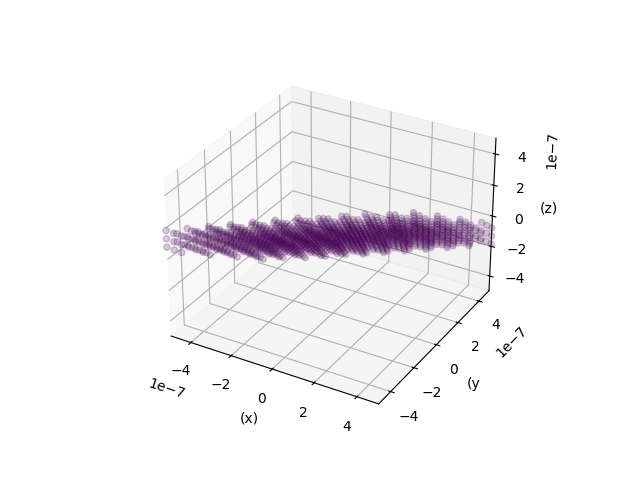

In [35]:
%matplotlib widget
#matplotlib inline
cm=plt.get_cmap('viridis',100)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*bpts.T,c=cm(val[idx]/np.max(T[:,i])),alpha=0.2)
ax.scatter(*(-bpts.T),c=cm(val[idx]/np.max(T[:,i])),alpha=0.2)

#ax.scatter(*(-Bnsym.T),c=cm(T[:,1]/np.max(T[:,1])),alpha=0.2)

#ax.plot_surface(*bpts.T,alpha=0.2)
#ax.scatter(*bsph.T)
ax.set_xlim(-Bf,Bf)
ax.set_ylim(-Bf,Bf)
ax.set_zlim(-Bf,Bf)

ax.set_xlabel("(x)")
ax.set_ylabel(r"(y")
ax.set_zlabel(r"(z)")

plt.show()


[ 2.63157895e-08 -5.00000000e-07  5.00000000e-07] [ 2.63157895e-08 -5.00000000e-07]


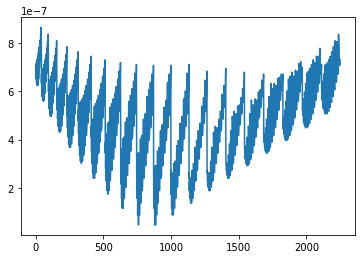

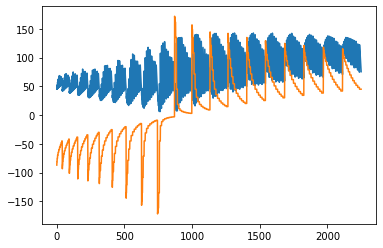

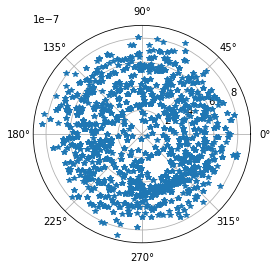

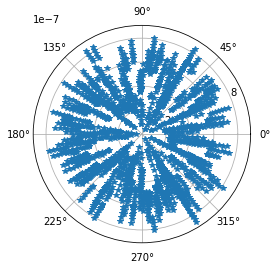

In [14]:
%matplotlib inline
plt.close()
rs=np.sqrt(np.sum(np.square(bpts),axis=1))
thetas=np.arccos(bpts[:,-1]/rs)*180/np.pi
phis=np.sign(bpts[:,1])*np.arccos(bpts[:,0]/np.sqrt(np.sum(np.square(bpts[:,:2]),axis=1)))*180/np.pi

print(bpts[0,:],bpts[0,:2])
plt.plot(rs)
plt.show()
plt.close()
plt.plot(thetas)
plt.plot(phis)
plt.show()
plt.close()
#plt.plot(thetas,rs,'*')
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(thetas, rs,'*')
ax.grid(True)
plt.show()
plt.close()
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(phis, rs,'*')
ax.grid(True)
plt.show()
plt.close()

In [15]:
T,Td=multiSweepOptical(Bnsym)


C:\Users\neb16\AppData\Local\Temp/ipykernel_13276/441718308.py:30: ComplexWarning:

Casting complex values to real discards the imaginary part

C:\Users\neb16\AppData\Local\Temp/ipykernel_13276/441718308.py:33: ComplexWarning:

Casting complex values to real discards the imaginary part



In [16]:
norm=lambda U: np.squeeze(U.H@U)

val=norm(np.matrix(T-target).T)


In [17]:
%%script False
fig = go.Figure(data=go.Isosurface(
    x=Bnsym[:,0],#Bx.flatten(),
    y=Bnsym[:,1],#By.flatten(),
    z=Bnsym[:,2],#Bz.flatten(),
    value=val,
    opacity=0.6,
    isomin=None,
    isomax=None,
    surface_count=20, # number of isosurfaces, 2 by default: only min and max
    colorbar_nticks=20, # colorbar ticks correspond to isosurface values
    caps=dict(x_show=False, y_show=False)
    ))
fig.show()

Couldn't find program: 'False'
